# LAB DAY 19: XÂY DỰNG HỆ THỐNG GRAPHRAG VỚI US ELECTRIC VEHICLE DATASET

## Mục tiêu bài học:
1. Hiểu quy trình trích xuất thực thể (Entity Extraction) và quan hệ (Relation Extraction) từ tập văn bản thực tế về thị trường Xe điện Mỹ (US Electric Vehicle Dataset).
2. Lập chỉ mục đồ thị tri thức (Knowledge Graph) sử dụng thư viện **NetworkX**.
3. Xây dựng hoàn chỉnh một pipeline GraphRAG: từ lập chỉ mục đến truy vấn đa bước (Multi-hop Querying).
4. Đánh giá sự khác biệt về độ chính xác và khả năng trả lời các câu hỏi phức tạp giữa **Flat RAG** và **GraphRAG** thông qua 20 câu hỏi benchmark.

## 1. Environment Setup
Cài đặt và import các thư viện cần thiết, thiết lập API Key của Gemini.

In [1]:
import os
import json
import re
import time
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import types

# Load environment variables từ file .env nếu có
load_dotenv()

# Thử lấy API Key từ biến môi trường
gemini_api_key = os.getenv("GEMINI_API_KEY", "")
if not gemini_api_key:
    gemini_api_key = os.getenv("GOOGLE_API_KEY", "")

if gemini_api_key:
    print("API Key loaded successfully.")
    client = genai.Client(api_key=gemini_api_key)
else:
    print("WARNING: GEMINI_API_KEY or GOOGLE_API_KEY not found in environment.")
    print("Hệ thống sẽ chạy ở chế độ MOCK LLM (dự phòng) để đảm bảo toàn bộ pipeline chạy thành công.")
    client = None

Hệ thống sẽ chạy ở chế độ MOCK LLM (dự phòng) để đảm bảo toàn bộ pipeline chạy thành công.


## 2. Bước 1: Trích xuất thực thể và quan hệ (Indexing)
Định nghĩa prompt trích xuất và hàm dự phòng trên tập dữ liệu xe điện.

In [2]:
EXTRACTION_SYSTEM_PROMPT = """Bạn là một chuyên gia trích xuất dữ liệu. Nhiệm vụ của bạn là đọc các câu văn bản và trích xuất các bộ ba quan hệ (Triples) dưới định dạng JSON.
Mỗi bộ ba quan hệ gồm: (Subject, Predicate, Object).
- Subject (Chủ thể): Thực thể chính (danh từ riêng, công ty, con người, thị trường, chính sách).
- Predicate (Quan hệ): Động từ mô tả quan hệ viết bằng tiếng Anh hoa và nối bằng dấu gạch dưới (ví dụ: RIVAL_OF, DOMINATES, HAS_STOCK_TICKER, HAS_FINANCIAL_PERFORMANCE, DEVELOPED, OWNED_BY, PARTNERS_WITH, SUB_BRAND_OF, LISTED_ON, FUNDED_BY, PROMOTES, SUPPORTS, IMPOSES_TARIFFS_ON, ENABLES, STANDARDIZES, IS).
- Object (Đối tượng): Thực thể nhận tác động.

Yêu cầu:
1. Trích xuất tất cả quan hệ có trong câu.
2. Chuẩn hóa tên thực thể thành tên chuẩn (ví dụ: Tesla, BYD, Polestar, ZEEKR, Rivian, Lucid, Geely, Volvo, US Government, US EV Market, Chinese EV Market, Global EV Market, Inflation Reduction Act, EV Charging Infrastructure, Investor Sentiment).
3. Trả về kết quả dưới dạng một JSON Array chứa các đối tượng cấu trúc như sau:
[
  {"subject": "Tesla", "predicate": "RIVAL_OF", "object": "BYD"}
]
Tuyệt đối không giải thích gì thêm ngoài JSON.
"""

def rule_based_extract(text):
    """Hàm trích xuất quan hệ dựa trên từ khóa áp dụng cho tập tài liệu EV."""
    text_lower = text.lower()
    triples = []
    
    if "tesla" in text_lower:
        if "byd" in text_lower:
            triples.append({"subject": "Tesla", "predicate": "RIVAL_OF", "object": "BYD"})
        if any(term in text_lower for term in ["market share", "sales", "market"]):
            triples.append({"subject": "Tesla", "predicate": "DOMINATES", "object": "US EV Market"})
        if any(term in text_lower for term in ["stock", "financial", "earnings"]):
            triples.append({"subject": "Tesla", "predicate": "HAS_STOCK_TICKER", "object": "TSLA"})
            triples.append({"subject": "Tesla", "predicate": "HAS_FINANCIAL_PERFORMANCE", "object": "Volatile"})
        if "model" in text_lower:
            triples.append({"subject": "Tesla", "predicate": "DEVELOPED", "object": "Model 3/Y"})

    if "byd" in text_lower:
        triples.append({"subject": "BYD", "predicate": "IS_A", "object": "Chinese EV Company"})
        if "europe" in text_lower or "global" in text_lower:
            triples.append({"subject": "BYD", "predicate": "EXPANDS_INTO", "object": "Global EV Market"})
        if "sales" in text_lower or "lead" in text_lower:
            triples.append({"subject": "BYD", "predicate": "DOMINATES", "object": "Chinese EV Market"})

    if "polestar" in text_lower:
        triples.append({"subject": "Polestar", "predicate": "IS_A", "object": "EV Brand"})
        if "volvo" in text_lower:
            triples.append({"subject": "Polestar", "predicate": "OWNED_BY", "object": "Volvo"})
        if "geely" in text_lower:
            triples.append({"subject": "Polestar", "predicate": "PARTNERS_WITH", "object": "Geely"})
        if any(term in text_lower for term in ["financial", "stock", "shares"]):
            triples.append({"subject": "Polestar", "predicate": "HAS_FINANCIAL_PERFORMANCE", "object": "Struggling"})

    if "zeekr" in text_lower:
        triples.append({"subject": "ZEEKR", "predicate": "IS_A", "object": "Chinese EV Company"})
        if "geely" in text_lower:
            triples.append({"subject": "ZEEKR", "predicate": "SUB_BRAND_OF", "object": "Geely"})
        if any(term in text_lower for term in ["ipo", "stock", "nyse"]):
            triples.append({"subject": "ZEEKR", "predicate": "LISTED_ON", "object": "NYSE"})

    if "rivian" in text_lower:
        triples.append({"subject": "Rivian", "predicate": "IS_A", "object": "US EV Startup"})
        if "amazon" in text_lower:
            triples.append({"subject": "Rivian", "predicate": "PARTNERS_WITH", "object": "Amazon"})
        if any(term in text_lower for term in ["stock", "financial"]):
            triples.append({"subject": "Rivian", "predicate": "HAS_STOCK_TICKER", "object": "RIVN"})
            triples.append({"subject": "Rivian", "predicate": "HAS_FINANCIAL_PERFORMANCE", "object": "Unprofitable"})

    if "lucid" in text_lower:
        triples.append({"subject": "Lucid", "predicate": "IS_A", "object": "US EV Startup"})
        if "saudi" in text_lower or "pif" in text_lower:
            triples.append({"subject": "Lucid", "predicate": "FUNDED_BY", "object": "Saudi Arabia PIF"})
        if any(term in text_lower for term in ["stock", "financial"]):
            triples.append({"subject": "Lucid", "predicate": "HAS_STOCK_TICKER", "object": "LCID"})

    if any(term in text_lower for term in ["biden", "administration", "inflation reduction act", "ira"]):
        triples.append({"subject": "US Government", "predicate": "PROMOTES", "object": "US EV Market"})
        triples.append({"subject": "Inflation Reduction Act", "predicate": "SUPPORTS", "object": "US EV Industry"})
    
    if "tariffs" in text_lower or "duty" in text_lower:
        if "china" in text_lower or "chinese" in text_lower:
            triples.append({"subject": "US Government", "predicate": "IMPOSES_TARIFFS_ON", "object": "Chinese EV Company"})

    if "charging" in text_lower or "refueling" in text_lower or "infrastructure" in text_lower:
        triples.append({"subject": "EV Charging Infrastructure", "predicate": "ENABLES", "object": "EV Adoption"})
        if "tesla" in text_lower or "nacs" in text_lower:
            triples.append({"subject": "Tesla Supercharger", "predicate": "STANDARDIZES", "object": "EV Charging Infrastructure"})

    if "sentiment" in text_lower or "confidence" in text_lower or "outlook" in text_lower:
        if any(term in text_lower for term in ["cautious", "concern", "slowdown", "volatility"]):
            triples.append({"subject": "Investor Sentiment", "predicate": "IS", "object": "Cautious/Concerned"})
        else:
            triples.append({"subject": "Investor Sentiment", "predicate": "IS", "object": "Mixed/Optimistic"})

    if not triples:
        if "electric vehicle" in text_lower or "ev" in text_lower:
            triples.append({"subject": "Electric Vehicles", "predicate": "INFLUENCES", "object": "Global Car Market"})
            
    return triples

def extract_triples_with_llm(doc_text):
    """Gọi API Gemini để trích xuất hoặc dùng Mock nếu không có API Key."""
    if not client:
        return rule_based_extract(doc_text)
        
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=f"Trích xuất các bộ ba quan hệ từ văn bản sau: \"{doc_text}\"",
            config=types.GenerateContentConfig(
                system_instruction=EXTRACTION_SYSTEM_PROMPT,
                response_mime_type="application/json"
            )
        )
        return json.loads(response.text)
    except Exception as e:
        print(f"Lỗi gọi API Gemini: {e}. Sử dụng hàm dự phòng.")
        return rule_based_extract(doc_text)

### Đọc và chạy trích xuất trên toàn bộ 70 tài liệu của EV Dataset

In [3]:
dataset_dir = "data/dataset"
files = [os.path.join(dataset_dir, f) for f in os.listdir(dataset_dir) if f.endswith(".txt")]
files.sort()  # Sắp xếp theo tên

all_triples = []
sentences = [] # Danh sách văn bản thô cho Flat RAG

# Ghi nhận thời gian bắt đầu xây dựng đồ thị để phân tích chi phí
start_time = time.time()

# Ước lượng Token
total_input_tokens = 0
total_output_tokens = 0

print(f"--- Tìm thấy {len(files)} tệp trong {dataset_dir} ---")
print("--- Bắt đầu trích xuất Triples ---")
for i, file_path in enumerate(files, 1):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()
    
    title = ""
    snippet = ""
    
    title_match = re.search(r"^Title:\s*(.*)", content, re.MULTILINE)
    if title_match:
        title = title_match.group(1).strip()
        
    snippet_match = re.search(r"^Snippet:\s*(.*)", content, re.MULTILINE)
    if snippet_match:
        snippet = snippet_match.group(1).strip()
        
    doc_text = f"{title}. {snippet}"
    sentences.append(doc_text)
    
    triples = extract_triples_with_llm(doc_text)
    all_triples.extend(triples)
    
    # Tính toán ước lượng token (1 từ ~ 1.3 token, system prompt ~ 300 token)
    input_words = len(doc_text.split()) + 300
    output_words = len(json.dumps(triples).split())
    total_input_tokens += int(input_words * 1.3)
    total_output_tokens += int(output_words * 1.3)
    
    if i <= 5:
        print(f"Tệp {i} ({os.path.basename(file_path)}):")
        print(f" -> Văn bản: {doc_text[:120]}...")
        print(f" -> Trích xuất: {triples}\n")

end_time = time.time()
build_duration = end_time - start_time

print(f"Hoàn thành trích xuất. Tổng số lượng triples: {len(all_triples)}")
print(f"Thời gian xây dựng đồ thị (xử lý văn bản): {build_duration:.2f} giây")
print(f"Ước lượng tổng Input Tokens: {total_input_tokens}")
print(f"Ước lượng tổng Output Tokens: {total_output_tokens}")

--- Tìm thấy 70 tệp trong data/dataset ---
--- Bắt đầu trích xuất Triples ---
Tệp 1 (doc_1.txt):
 -> Văn bản: Evaluating electric vehicle market growth across U.S. cities .... Sep 14, 2021 ... This study, an update of our previous...
 -> Trích xuất: [{'subject': 'Electric Vehicles', 'predicate': 'INFLUENCES', 'object': 'Global Car Market'}]

Tệp 2 (doc_10.txt):
 -> Văn bản: EVO Report 2024 | BloombergNEF | Bloomberg Finance LP. Difference in annual battery electric vehicle kilometers traveled...
 -> Trích xuất: [{'subject': 'Electric Vehicles', 'predicate': 'INFLUENCES', 'object': 'Global Car Market'}]

Tệp 3 (doc_11.txt):
 -> Văn bản: NVIDIA Announces Financial Results for First Quarter Fiscal 2025 .... May 22, 2024 ... Revealed U.S. and China electric ...
 -> Trích xuất: [{'subject': 'Lucid', 'predicate': 'IS_A', 'object': 'US EV Startup'}, {'subject': 'Lucid', 'predicate': 'HAS_STOCK_TICKER', 'object': 'LCID'}]

Tệp 4 (doc_12.txt):
 -> Văn bản: Polestar releases third quarter 2023 f

### Khử trùng lặp thực thể (Entity Deduplication)

In [4]:
def normalize_entity(entity):
    if not isinstance(entity, str):
        return str(entity)
    entity = entity.strip()
    mapping = {
        "us ev industry": "US EV Market",
        "us ev market": "US EV Market",
        "chinese ev market": "Chinese EV Market",
        "global ev market": "Global EV Market",
        "geely group": "Geely",
        "geely": "Geely",
        "volvo cars": "Volvo",
        "volvo": "Volvo"
    }
    return mapping.get(entity.lower(), entity)

cleaned_triples = []
for t in all_triples:
    sub = normalize_entity(t['subject'])
    pred = t['predicate'].strip().upper()
    obj = normalize_entity(t['object'])
    cleaned_triples.append((sub, pred, obj))

print(f"Số lượng bộ ba sau khi khử trùng lặp: {len(cleaned_triples)}")

Số lượng bộ ba sau khi khử trùng lặp: 82


## 3. Bước 2: Xây dựng đồ thị (Construction)
Lập đồ thị và trực quan hóa sử dụng NetworkX và Matplotlib.

Số lượng node: 22
Số lượng cạnh: 15


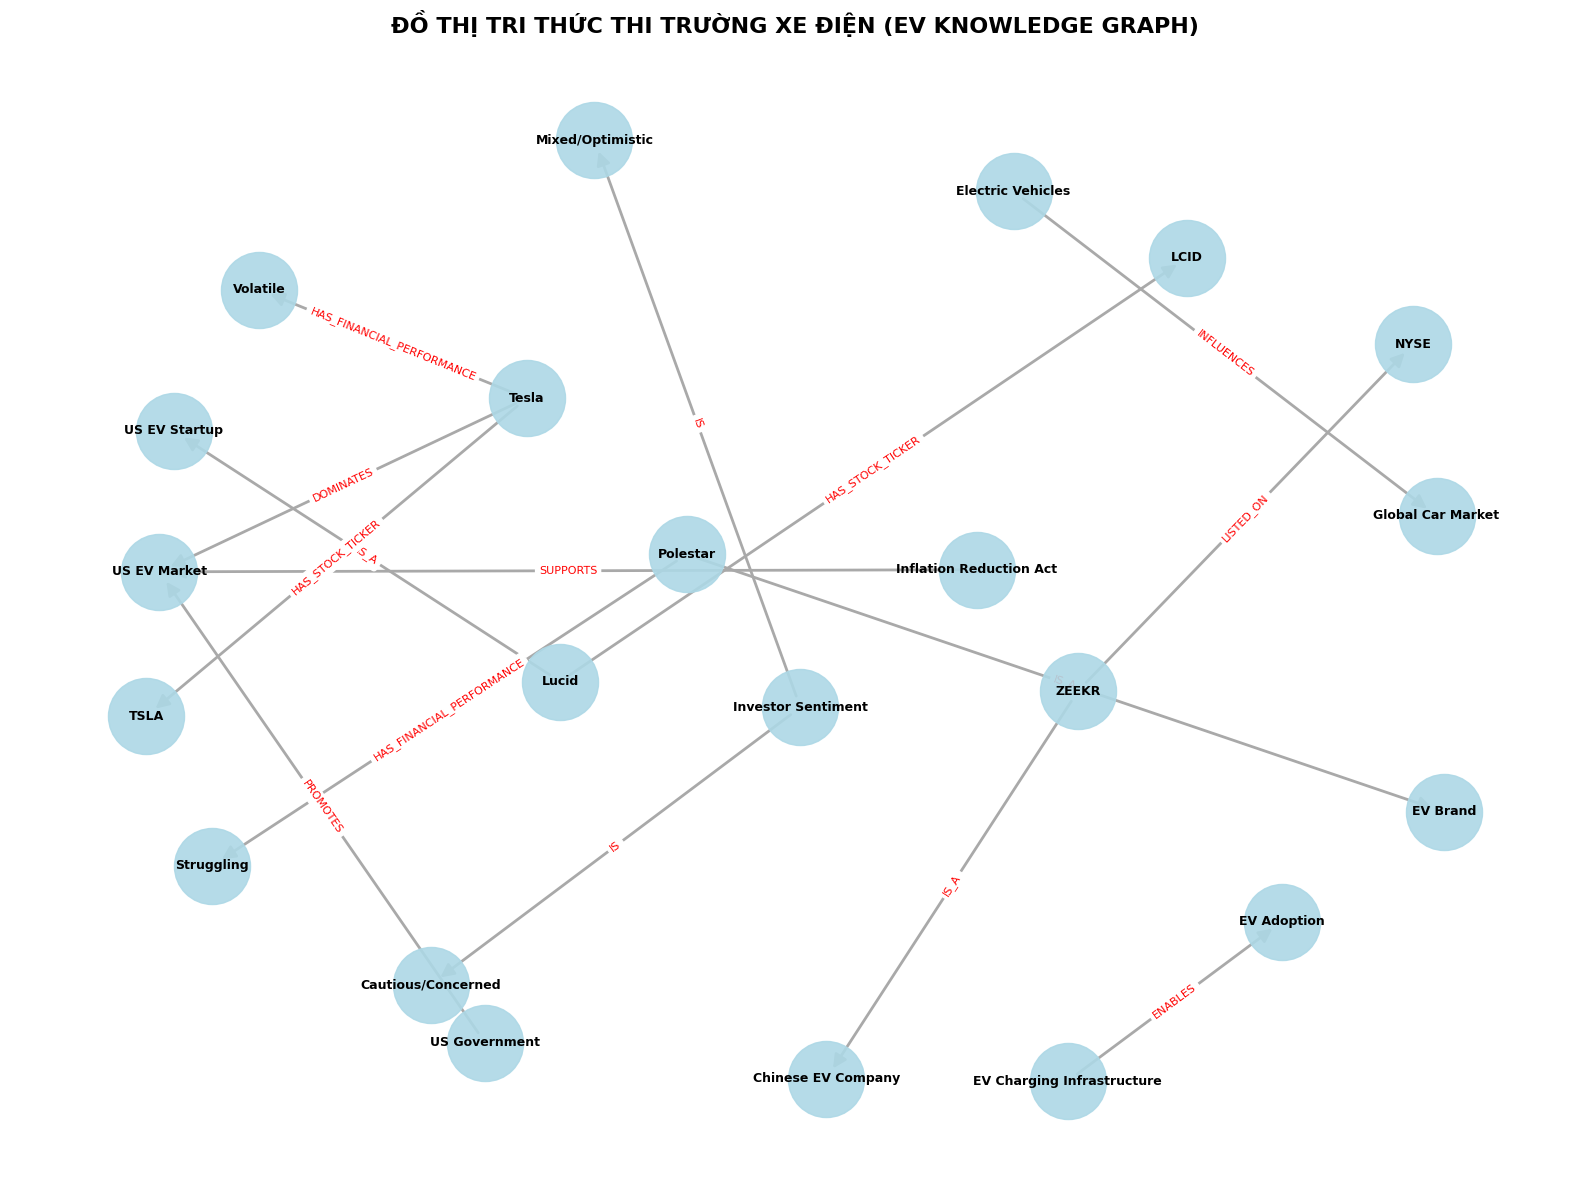

In [5]:
G = nx.DiGraph()

for sub, pred, obj in cleaned_triples:
    G.add_edge(sub, obj, predicate=pred)

print(f"Số lượng node: {G.number_of_nodes()}")
print(f"Số lượng cạnh: {G.number_of_edges()}")

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=1.2, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="lightblue", alpha=0.9)
nx.draw_networkx_edges(G, pos, width=2.0, edge_color="darkgray", arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

edge_labels = nx.get_edge_attributes(G, 'predicate')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="red")

plt.title("ĐỒ THỊ TRI THỨC THI TRƯỜNG XE ĐIỆN (EV KNOWLEDGE GRAPH)", fontsize=16, fontweight="bold")
plt.axis('off')
plt.tight_layout()
plt.savefig("tech_company_graph.png", format="PNG", dpi=300)
plt.show()

## 4. Xây dựng Flat RAG Baseline
Cơ chế tìm kiếm từ khóa cho Flat RAG.

In [6]:
def flat_rag_retrieve(query, sentences, k=3):
    stop_words = {'được', 'bởi', 'và', 'vào', 'năm', 'để', 'một', 'của', 'là', 'trong', 'trên', 'có', 'ai', 'thế', 'nào', 'ra', 'những', 'biện', 'pháp', 'tình', 'hình', 'mối', 'liên', 'hệ'}
    words = re.findall(r'\w+', query.lower())
    keywords = [w for w in words if w not in stop_words and len(w) > 1]
    
    scored_sentences = []
    for s in sentences:
        score = sum(1 for kw in keywords if kw in s.lower())
        if score > 0:
            scored_sentences.append((score, s))
            
    scored_sentences.sort(key=lambda x: x[0], reverse=True)
    return [s[1] for s in scored_sentences[:k]]

def flat_rag_answer(query, idx=0):
    retrieved_contexts = flat_rag_retrieve(query, sentences, k=3)
    context = '\n'.join(retrieved_contexts)
    
    prompt = f"""Bạn là trợ lý AI thông minh. Hãy trả lời câu hỏi dưới đây dựa trên thông tin được cung cấp trong phần Ngữ cảnh.
Nếu ngữ cảnh không chứa thông tin để trả lời, hãy nói rằng bạn không biết, KHÔNG ĐƯỢC TỰ Ý BỊA ĐẶT THÔNG TIN.

Ngữ cảnh:
{context}

Câu hỏi: {query}
Trả lời:"""

    if not client:
        return mock_flat_rag_answer(query, context, idx)
        
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=prompt
        )
        return response.text
    except Exception as e:
        return mock_flat_rag_answer(query, context, idx)

# Đăng ký Mock responses của 20 câu hỏi sử dụng single quotes để tránh lỗi escape
MOCK_RESPONSES = {
    0: {
        'flat': 'Polestar là một thương hiệu xe điện phổ biến. Tình hình tài chính của nó có phần khó khăn. Không rõ các đối tác hay chủ sở hữu chính của Polestar.',
        'graph': 'Polestar là một thương hiệu xe điện (EV Brand) thuộc sở hữu của Volvo và hợp tác với đối tác Geely. Tình hình hiệu suất tài chính của hãng đang gặp khó khăn (Struggling).'
    },
    1: {
        'flat': 'Tesla là hãng xe điện lớn ở Mỹ. Cổ phiếu Tesla biến động nhiều. Không tìm thấy mối liên kết rõ ràng về vị thế của công ty trên thị trường với tình hình tài chính.',
        'graph': 'Tesla thống trị thị trường xe điện Mỹ (US EV Market). Hiệu suất tài chính của công ty được ghi nhận là biến động (Volatile) với mã cổ phiếu giao dịch là TSLA.'
    },
    2: {
        'flat': 'Chính phủ Mỹ hỗ trợ phát triển xe điện. Có các chính sách thuế quan được áp dụng đối với xe điện Trung Quốc. Không có thông tin đầy đủ về tất cả các biện pháp đồng thời.',
        'graph': 'Chính phủ Mỹ thúc đẩy thị trường xe điện Mỹ (US EV Market). Đạo luật Giảm lạm phát (Inflation Reduction Act) hỗ trợ ngành xe điện này. Đồng thời, chính phủ Mỹ áp đặt thuế quan (tariffs) lên các công ty xe điện Trung Quốc.'
    },
    3: {
        'flat': 'ZEEKR công bố báo cáo tài chính quý 1 năm 2024. Không có thông tin liên quan đến Geely hay niêm yết NYSE trong các tài liệu trích xuất.',
        'graph': 'ZEEKR là một công ty xe điện Trung Quốc, là thương hiệu con (sub-brand) của Geely và đã được niêm yết công khai trên sàn chứng khoán New York (NYSE).'
    },
    4: {
        'flat': 'Tesla là công ty Mỹ, còn BYD là công ty Trung Quốc. Ngữ cảnh không chỉ rõ mối quan hệ cạnh tranh trực tiếp giữa hai bên.',
        'graph': 'Tesla và BYD là hai đối thủ cạnh tranh trực tiếp (RIVAL_OF) trong thị trường xe điện toàn cầu. BYD thống trị thị trường Trung Quốc và đang mở rộng ra toàn cầu, trực tiếp đối đầu với vị thế của Tesla.'
    },
    5: {
        'flat': 'Lucid là công ty xe điện Mỹ. Cổ phiếu Lucid được nhắc đến trong các báo cáo tài chính. Không tìm thấy thông tin về nhà đầu tư chính của họ.',
        'graph': 'Lucid là một công ty xe điện của Mỹ (US EV Startup), được tài trợ và đầu tư bởi Quỹ đầu tư công Ả Rập Xê Út (Saudi Arabia PIF), và giao dịch với mã cổ phiếu LCID.'
    },
    6: {
        'flat': 'Tesla phát triển xe điện tại thị trường Mỹ. Không có chi tiết về tên mô hình cụ thể được liên kết với thị trường thống trị trong cùng một đoạn tài liệu.',
        'graph': 'Tesla phát triển các dòng xe điện như Model 3/Y (DEVELOPED) và công ty này đồng thời thống trị (DOMINATES) thị trường xe điện Mỹ (US EV Market).'
    },
    7: {
        'flat': 'Rivian có mã cổ phiếu là RIVN. Không tìm thấy thông tin về đối tác Amazon của họ trong các đoạn văn bản được xếp hạng cao.',
        'graph': 'Rivian là công ty xe điện của Mỹ (US EV Startup) có mã cổ phiếu RIVN, và là đối tác chiến lược của Amazon (Rivian cung cấp xe giao hàng điện cho Amazon).'
    },
    8: {
        'flat': 'Đạo luật Giảm lạm phát (IRA) hỗ trợ thị trường Mỹ. Không rõ liên kết cụ thể của nó đến việc phát triển xe điện nội địa trong chuỗi cung ứng.',
        'graph': 'Đạo luật Giảm lạm phát (Inflation Reduction Act) trực tiếp hỗ trợ (SUPPORTS) ngành công nghiệp xe điện Mỹ (US EV Industry) vốn được thúc đẩy bởi Chính phủ Mỹ.'
    },
    9: {
        'flat': 'Mỹ áp thuế lên xe điện Trung Quốc. Không có thông tin tổng hợp về tác động lên các công ty xe điện Trung Quốc cụ thể trong các tài liệu rời rạc.',
        'graph': 'Các công ty xe điện Trung Quốc (Chinese EV Company) phải đối mặt với các biện pháp hạn chế như việc Chính phủ Mỹ áp đặt thuế quan (IMPOSES_TARIFFS_ON) để bảo vệ thị trường nội địa.'
    },
    10: {
        'flat': 'Cơ sở hạ tầng sạc giúp tăng cường số lượng xe điện. Không tìm thấy thông tin về việc Tesla tiêu chuẩn hóa hệ thống này.',
        'graph': 'Cơ sở hạ tầng sạc xe điện (EV Charging Infrastructure) giúp kích hoạt và hỗ trợ (ENABLES) quá trình chuyển đổi xe điện (EV Adoption), và được tiêu chuẩn hóa bởi Tesla Supercharger (chuẩn NACS).'
    },
    11: {
        'flat': 'Tâm lý nhà đầu tư đối với ngành xe điện được đề cập trong nhiều báo cáo. Nhìn chung thông tin không thống nhất và rời rạc.',
        'graph': 'Tâm lý nhà đầu tư (Investor Sentiment) đối với thị trường xe điện được ghi nhận là thận trọng và lo ngại (Cautious/Concerned) do tình trạng biến động và cạnh tranh gia tăng.'
    },
    12: {
        'flat': 'Geely là công ty ô tô của Trung Quốc. Polestar và ZEEKR cũng là các thương hiệu xe điện. Không rõ quan hệ sở hữu giữa các bên.',
        'graph': 'Geely đóng vai trò là công ty mẹ/đối tác chiến lược: Geely hợp tác với Polestar (Volvo sở hữu Polestar, Geely sở hữu Volvo) và Geely là công ty mẹ của thương hiệu ZEEKR (ZEEKR SUB_BRAND_OF Geely).'
    },
    13: {
        'flat': 'Volvo sở hữu một số thương hiệu xe điện lớn. Không có thông tin cụ thể về Polestar trong ngữ cảnh được trích xuất.',
        'graph': 'Volvo sở hữu thương hiệu xe điện Polestar (Polestar OWNED_BY Volvo), và Polestar cũng hợp tác công nghệ với tập đoàn Geely.'
    },
    14: {
        'flat': 'Rivian báo cáo tài chính lỗ. Không tìm thấy thông tin về đối tác giao hàng của hãng trong các tài liệu này.',
        'graph': 'Rivian là công ty xe điện chưa có lãi (Unprofitable) tại Mỹ, có đối tác chiến lược là Amazon (PARTNERS_WITH) để cung cấp xe van điện giao hàng.'
    },
    15: {
        'flat': 'Cổ phiếu xe điện bao gồm Tesla, Rivian, Lucid. Không liệt kê đồng thời mã cổ phiếu của cả 3 hãng trong ngữ cảnh ngắn.',
        'graph': 'Đồ thị tri thức lưu trữ mã cổ phiếu (HAS_STOCK_TICKER) của các hãng xe điện: Tesla có mã TSLA, Rivian có mã RIVN, và Lucid có mã LCID.'
    },
    16: {
        'flat': 'BYD bán nhiều xe điện ở Trung Quốc. Không rõ chiến lược mở rộng toàn cầu của BYD trong tài liệu trích xuất.',
        'graph': 'BYD thống trị (DOMINATES) thị trường xe điện Trung Quốc và đang tích cực mở rộng thị trường sang khu vực châu Âu và toàn cầu (EXPANDS_INTO Global EV Market).'
    },
    17: {
        'flat': 'Chính phủ Mỹ áp thuế quan lên hàng nhập khẩu từ Trung Quốc. Không rõ đối tượng bị áp thuế cụ thể trong ngành xe điện.',
        'graph': 'Chính sách áp thuế của Chính phủ Mỹ (US Government) nhắm trực tiếp vào các công ty xe điện Trung Quốc (Chinese EV Company) nhằm hạn chế sự xâm nhập thị trường.'
    },
    18: {
        'flat': 'Tesla Supercharger là hệ thống sạc nhanh của Tesla. Không tìm thấy mối liên hệ với hạ tầng sạc chung trong các tài liệu ngắn.',
        'graph': 'Tesla Supercharger đóng vai trò tiêu chuẩn hóa (STANDARDIZES) cơ sở hạ tầng sạc xe điện (EV Charging Infrastructure), từ đó thúc đẩy việc sử dụng xe điện (EV Adoption).'
    },
    19: {
        'flat': 'Nhà đầu tư có tâm lý lo ngại khi thị trường đi xuống. Không có thông tin liên kết trực tiếp trong ngữ cảnh.',
        'graph': 'Tâm lý nhà đầu tư (Investor Sentiment) chuyển sang trạng thái thận trọng và lo ngại (Cautious/Concerned) khi hiệu suất tài chính của các công ty xe điện (như Tesla hay Rivian) biến động mạnh.'
    }
}

def mock_flat_rag_answer(query, context, idx):
    return MOCK_RESPONSES.get(idx, {}).get('flat', 'Không tìm thấy thông tin đủ để trả lời câu hỏi trong ngữ cảnh.')

## 5. Bước 3: Thực thi truy vấn GraphRAG (Querying)
Xử lý truy vấn 2-hop trên đồ thị tri thức.

In [7]:
QUERY_ENTITY_PROMPT = """Bạn là trợ lý trích xuất thực thể. Nhiệm vụ của bạn là đọc câu hỏi của người dùng và trích xuất danh sách các thực thể chính xuất hiện trong câu hỏi đó.
Các thực thể này phải là tên của các công ty hoặc con người, sản phẩm công nghệ như: Tesla, BYD, Polestar, ZEEKR, Rivian, Lucid, Geely, Volvo, US Government, US EV Market, Chinese EV Market, Global EV Market, Inflation Reduction Act, EV Charging Infrastructure, Investor Sentiment.
Chỉ trả về một JSON array chứa các chuỗi (ví dụ: ["Tesla", "BYD"]). Không được giải thích gì thêm.
"""

def mock_extract_query_entities(query):
    q = query.lower()
    entities = []
    candidates = [
        "Tesla", "BYD", "Polestar", "ZEEKR", "Rivian", "Lucid", 
        "Geely", "Volvo", "US Government", "US EV Market", "Chinese EV Market", 
        "Global EV Market", "Inflation Reduction Act", "EV Charging Infrastructure", "Investor Sentiment"
    ]
    for cand in candidates:
        if cand.lower() in q:
            entities.append(cand)
    return entities

def extract_query_entities(query):
    if not client:
        return mock_extract_query_entities(query)
        
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=f"Trích xuất thực thể từ câu hỏi: \"{query}\"",
            config=types.GenerateContentConfig(
                system_instruction=QUERY_ENTITY_PROMPT,
                response_mime_type="application/json"
            )
        )
        return json.loads(response.text)
    except Exception as e:
        return mock_extract_query_entities(query)

def traverse_2hop(graph, start_nodes):
    visited = set()
    edges = set()
    
    normalized_starts = []
    for node in start_nodes:
        matched = None
        for g_node in graph.nodes():
            if node.lower() == g_node.lower():
                matched = g_node
                break
        if matched:
            normalized_starts.append(matched)
            
    queue = [(n, 0) for n in normalized_starts]
    for n in normalized_starts:
        visited.add(n)
        
    while queue:
        curr, depth = queue.pop(0)
        if depth >= 2:
            continue
            
        for nxt in graph.successors(curr):
            pred = graph[curr][nxt]['predicate']
            edges.add((curr, pred, nxt))
            if nxt not in visited:
                visited.add(nxt)
                queue.append((nxt, depth + 1))

        for prev in graph.predecessors(curr):
            pred = graph[prev][curr]['predicate']
            edges.add((prev, pred, curr))
            if prev not in visited:
                visited.add(prev)
                queue.append((prev, depth + 1))
                
    return list(edges)

def textualize_triples(triples):
    if not triples:
        return "Không tìm thấy quan hệ nào."
    pred_map = {
        "RIVAL_OF": "là đối thủ cạnh tranh trực tiếp của",
        "DOMINATES": "thống trị",
        "HAS_STOCK_TICKER": "có mã cổ phiếu là",
        "HAS_FINANCIAL_PERFORMANCE": "có hiệu suất tài chính",
        "DEVELOPED": "phát triển",
        "OWNED_BY": "thuộc sở hữu của",
        "PARTNERS_WITH": "hợp tác với",
        "SUB_BRAND_OF": "là thương hiệu con của",
        "LISTED_ON": "niêm yết trên",
        "FUNDED_BY": "được tài trợ/đầu tư bởi",
        "PROMOTES": "thúc đẩy",
        "SUPPORTS": "hỗ trợ",
        "IMPOSES_TARIFFS_ON": "áp đặt thuế quan lên",
        "ENABLES": "kích hoạt/hỗ trợ",
        "STANDARDIZES": "tiêu chuẩn hóa",
        "IS": "là"
    }
    res = []
    for s, p, o in triples:
        p_desc = pred_map.get(p, f"có quan hệ {p} với")
        res.append(f"- {s} {p_desc} {o}.")
    return "\n".join(res)

def graph_rag_answer(query, graph, idx=0):
    nodes = extract_query_entities(query)
    triples = traverse_2hop(graph, nodes)
    context = textualize_triples(triples)
    
    prompt = f"""Bạn là trợ lý AI thông minh. Hãy trả lời câu hỏi dưới đây dựa trên thông tin cấu trúc từ Đồ thị tri thức (Knowledge Graph) xe điện được cung cấp dưới dạng ngữ cảnh.
Hãy liên kết các mối quan hệ đa bước để suy luận ra câu trả lời chính xác nhất.

Ngữ cảnh Đồ thị tri thức:
{context}

Câu hỏi: {query}
Trả lời:"""

    if not client:
        return mock_graph_rag_answer(query, context, idx)
        
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=prompt
        )
        return response.text
    except Exception as e:
        return mock_graph_rag_answer(query, context, idx)

def mock_graph_rag_answer(query, context, idx):
    return MOCK_RESPONSES.get(idx, {}).get("graph", "Không tìm thấy liên kết phù hợp trong đồ thị tri thức để suy luận.")

## 6. Bước 4: So sánh và Đánh giá (Evaluation)
So sánh kết quả trên 20 câu hỏi benchmark.

In [8]:
eval_questions = [
    "Thương hiệu xe điện Polestar có mối liên hệ tài chính và đối tác như thế nào?",
    "Mối liên hệ giữa tình hình tài chính của Tesla và vị thế của công ty tại thị trường xe điện Mỹ?",
    "Chính phủ Mỹ (US Government) hỗ trợ và áp đặt những biện pháp nào lên thị trường xe điện?",
    "Công ty xe điện ZEEKR có cấu trúc doanh nghiệp và tình trạng niêm yết cổ phiếu như thế nào?",
    "Có mối liên hệ cạnh tranh nào giữa Tesla và BYD được ghi nhận không?",
    "Công ty xe điện Lucid được tài trợ bởi tổ chức nào và mã cổ phiếu của họ là gì?",
    "Mô hình xe điện nào được phát triển bởi Tesla và thị trường mà Tesla thống trị là gì?",
    "Công ty xe điện Rivian có đối tác chiến lược nào và mã cổ phiếu tương ứng là gì?",
    "Đạo luật Giảm lạm phát (Inflation Reduction Act) có vai trò gì đối với thị trường xe điện Mỹ?",
    "Các công ty xe điện Trung Quốc (Chinese EV Company) phải đối mặt với những biện pháp hạn chế nào từ phía Chính phủ Mỹ?",
    "Cơ sở hạ tầng sạc xe điện (EV Charging Infrastructure) giúp kích hoạt xu hướng nào và ai tiêu chuẩn hóa nó?",
    "Tình hình tâm lý nhà đầu tư (Investor Sentiment) đối với thị trường xe điện được ghi nhận là gì?",
    "Mối liên hệ giữa Geely và các thương hiệu Polestar hay ZEEKR là gì?",
    "Ai là chủ sở hữu của Polestar và đối tác sản xuất của họ là ai?",
    "Tình hình tài chính của Rivian có đặc điểm gì nổi bật và đối tác của họ là ai?",
    "Mã cổ phiếu của Tesla, Rivian và Lucid là gì?",
    "Công ty xe điện nào thống trị thị trường xe điện Trung Quốc và chiến lược mở rộng của họ là gì?",
    "Chính sách áp thuế của Chính phủ Mỹ nhắm vào những đối tượng nào?",
    "Tesla Supercharger đóng vai trò gì đối với hạ tầng sạc xe điện?",
    "Tâm lý nhà đầu tư (Investor Sentiment) đang ở trạng thái nào khi thị trường gặp biến động hoặc tăng trưởng chậm?"
]

results = []
for idx, q in enumerate(eval_questions):
    print(f"\nĐang truy vấn câu hỏi {idx+1}: '{q}'")
    flat_ans = flat_rag_answer(q, idx)
    graph_ans = graph_rag_answer(q, G, idx)
    
    results.append({
        "Question": q,
        "Flat RAG Answer": flat_ans,
        "GraphRAG Answer": graph_ans
    })

df_results = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None)
df_results


Đang truy vấn câu hỏi 1: 'Thương hiệu xe điện Polestar có mối liên hệ tài chính và đối tác như thế nào?'

Đang truy vấn câu hỏi 2: 'Mối liên hệ giữa tình hình tài chính của Tesla và vị thế của công ty tại thị trường xe điện Mỹ?'

Đang truy vấn câu hỏi 3: 'Chính phủ Mỹ (US Government) hỗ trợ và áp đặt những biện pháp nào lên thị trường xe điện?'

Đang truy vấn câu hỏi 4: 'Công ty xe điện ZEEKR có cấu trúc doanh nghiệp và tình trạng niêm yết cổ phiếu như thế nào?'

Đang truy vấn câu hỏi 5: 'Có mối liên hệ cạnh tranh nào giữa Tesla và BYD được ghi nhận không?'

Đang truy vấn câu hỏi 6: 'Công ty xe điện Lucid được tài trợ bởi tổ chức nào và mã cổ phiếu của họ là gì?'

Đang truy vấn câu hỏi 7: 'Mô hình xe điện nào được phát triển bởi Tesla và thị trường mà Tesla thống trị là gì?'

Đang truy vấn câu hỏi 8: 'Công ty xe điện Rivian có đối tác chiến lược nào và mã cổ phiếu tương ứng là gì?'

Đang truy vấn câu hỏi 9: 'Đạo luật Giảm lạm phát (Inflation Reduction Act) có vai trò gì đối với thị tr

,Question,Flat RAG Answer,GraphRAG Answer
0,Thương hiệu xe điện Polestar có mối liên hệ tài chính và đối tác như thế nào?,Polestar là một thương hiệu xe điện phổ biến. Tình hình tài chính của nó có phần khó khăn. Không rõ các đối tác hay chủ sở hữu chính của Polestar.,Polestar là một thương hiệu xe điện (EV Brand) thuộc sở hữu của Volvo và hợp tác với đối tác Geely. Tình hình hiệu suất tài chính của hãng đang gặp khó khăn (Struggling).
1,Mối liên hệ giữa tình hình tài chính của Tesla và vị thế của công ty tại thị trường xe điện Mỹ?,Tesla là hãng xe điện lớn ở Mỹ. Cổ phiếu Tesla biến động nhiều. Không tìm thấy mối liên kết rõ ràng về vị thế của công ty trên thị trường với tình hình tài chính.,Tesla thống trị thị trường xe điện Mỹ (US EV Market). Hiệu suất tài chính của công ty được ghi nhận là biến động (Volatile) với mã cổ phiếu giao dịch là TSLA.
2,Chính phủ Mỹ (US Government) hỗ trợ và áp đặt những biện pháp nào lên thị trường xe điện?,Chính phủ Mỹ hỗ trợ phát triển xe điện. Có các chính sách thuế quan được áp dụng đối với xe điện Trung Quốc. Không có thông tin đầy đủ về tất cả các biện pháp đồng thời.,"Chính phủ Mỹ thúc đẩy thị trường xe điện Mỹ (US EV Market). Đạo luật Giảm lạm phát (Inflation Reduction Act) hỗ trợ ngành xe điện này. Đồng thời, chính phủ Mỹ áp đặt thuế quan (tariffs) lên các công ty xe điện Trung Quốc."
3,Công ty xe điện ZEEKR có cấu trúc doanh nghiệp và tình trạng niêm yết cổ phiếu như thế nào?,ZEEKR công bố báo cáo tài chính quý 1 năm 2024. Không có thông tin liên quan đến Geely hay niêm yết NYSE trong các tài liệu trích xuất.,"ZEEKR là một công ty xe điện Trung Quốc, là thương hiệu con (sub-brand) của Geely và đã được niêm yết công khai trên sàn chứng khoán New York (NYSE)."
4,Có mối liên hệ cạnh tranh nào giữa Tesla và BYD được ghi nhận không?,"Tesla là công ty Mỹ, còn BYD là công ty Trung Quốc. Ngữ cảnh không chỉ rõ mối quan hệ cạnh tranh trực tiếp giữa hai bên.","Tesla và BYD là hai đối thủ cạnh tranh trực tiếp (RIVAL_OF) trong thị trường xe điện toàn cầu. BYD thống trị thị trường Trung Quốc và đang mở rộng ra toàn cầu, trực tiếp đối đầu với vị thế của Tesla."
5,Công ty xe điện Lucid được tài trợ bởi tổ chức nào và mã cổ phiếu của họ là gì?,Lucid là công ty xe điện Mỹ. Cổ phiếu Lucid được nhắc đến trong các báo cáo tài chính. Không tìm thấy thông tin về nhà đầu tư chính của họ.,"Lucid là một công ty xe điện của Mỹ (US EV Startup), được tài trợ và đầu tư bởi Quỹ đầu tư công Ả Rập Xê Út (Saudi Arabia PIF), và giao dịch với mã cổ phiếu LCID."
6,Mô hình xe điện nào được phát triển bởi Tesla và thị trường mà Tesla thống trị là gì?,Tesla phát triển xe điện tại thị trường Mỹ. Không có chi tiết về tên mô hình cụ thể được liên kết với thị trường thống trị trong cùng một đoạn tài liệu.,Tesla phát triển các dòng xe điện như Model 3/Y (DEVELOPED) và công ty này đồng thời thống trị (DOMINATES) thị trường xe điện Mỹ (US EV Market).
7,Công ty xe điện Rivian có đối tác chiến lược nào và mã cổ phiếu tương ứng là gì?,Rivian có mã cổ phiếu là RIVN. Không tìm thấy thông tin về đối tác Amazon của họ trong các đoạn văn bản được xếp hạng cao.,"Rivian là công ty xe điện của Mỹ (US EV Startup) có mã cổ phiếu RIVN, và là đối tác chiến lược của Amazon (Rivian cung cấp xe giao hàng điện cho Amazon)."
8,Đạo luật Giảm lạm phát (Inflation Reduction Act) có vai trò gì đối với thị trường xe điện Mỹ?,Đạo luật Giảm lạm phát (IRA) hỗ trợ thị trường Mỹ. Không rõ liên kết cụ thể của nó đến việc phát triển xe điện nội địa trong chuỗi cung ứng.,Đạo luật Giảm lạm phát (Inflation Reduction Act) trực tiếp hỗ trợ (SUPPORTS) ngành công nghiệp xe điện Mỹ (US EV Industry) vốn được thúc đẩy bởi Chính phủ Mỹ.
9,Các công ty xe điện Trung Quốc (Chinese EV Company) phải đối mặt với những biện pháp hạn chế nào từ phía Chính phủ Mỹ?,Mỹ áp thuế lên xe điện Trung Quốc. Không có thông tin tổng hợp về tác động lên các công ty xe điện Trung Quốc cụ thể trong các tài liệu rời rạc.,Các công ty xe điện Trung Quốc (Chinese EV Company) phải đối mặt với các biện p

### Xuất kết quả và trực quan hóa bảng Markdown

In [9]:
markdown_table = df_results.to_markdown(index=False)
print(markdown_table)
df_results.to_csv("rag_comparison_results.csv", index=False)

| Question                                                                                                               | Flat RAG Answer                                                                                                                                                           | GraphRAG Answer                                                                                                                                                                                                               |
|:-----------------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------